<a href="https://colab.research.google.com/github/kunal190399/chatbot/blob/main/3d_structural_pattern_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# We install two libraries that Google Colab doesn't have by default.
# rdkit  → reads and analyses molecules
# umap-learn → shrinks high-dimensional data into 2D so we can plot it

!pip install rdkit umap-learn --quiet
print("✅ Done installing")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 34.1 MB/s eta 0:00:00
✅ Done installing


In [3]:
# Think of "import" like opening an app before you use it.
# We give each library a short nickname to save typing.

import pandas as pd                          # spreadsheet-style data tables
import numpy as np                           # maths on lists of numbers
import matplotlib.pyplot as plt              # drawing charts and graphs
import seaborn as sns                        # makes charts look nicer
import warnings
warnings.filterwarnings('ignore')            # hides minor warning messages

from rdkit import Chem                       # core molecule reader
from rdkit.Chem import Descriptors           # calculates molecule properties
from rdkit.Chem import rdMolDescriptors      # more molecule measurements
from rdkit.Chem import Draw                  # draws pictures of molecules
from rdkit.Chem import AllChem               # 3D coordinate generation

from sklearn.preprocessing import StandardScaler   # normalises numbers
from sklearn.decomposition import PCA              # first dimension reducer
from sklearn.cluster import KMeans                 # grouping algorithm
from sklearn.metrics import silhouette_score       # measures cluster quality

import umap                                  # better dimension reducer

print("✅ All libraries loaded")

✅ All libraries loaded


In [4]:
# We use a famous public dataset called ZINC.
# It contains 250,000 real drug-like molecules as SMILES strings.
# SMILES = a text shorthand for molecules. Example: "CCO" = ethanol.

import urllib.request

print("Downloading dataset...")
url = "https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv"
urllib.request.urlretrieve(url, "molecules.csv")

# Load into a pandas DataFrame — like an Excel table in Python
df = pd.read_csv("molecules.csv")
print(f"Full dataset: {df.shape[0]:,} molecules, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

# ── Take a sample of 2,000 ──────────────────────────────────────────
# 250,000 is too slow for a laptop/Colab.
# random_state=42 means we always get the SAME sample → reproducible research.
df_sample = df.sample(n=2000, random_state=42).reset_index(drop=True)
print(f"\nWorking sample: {len(df_sample)} molecules")

# ── Convert SMILES text → RDKit molecule objects ────────────────────
# Chem.MolFromSmiles() reads the text and builds an internal 3D model.
# Returns None if the string is invalid — we drop those rows.
df_sample['mol'] = df_sample['smiles'].apply(Chem.MolFromSmiles)
df_sample = df_sample[df_sample['mol'].notna()].reset_index(drop=True)
print(f"Valid molecules after parsing: {len(df_sample)}")

# Preview
print("\nFirst 3 SMILES strings:")
for i, row in df_sample.head(3).iterrows():
    print(f"  [{i}] {row['smiles']}")

Full dataset: 249,455 molecules, 4 columns
Columns: ['smiles', 'logP', 'qed', 'SAS']

Working sample: 2000 molecules
Valid molecules after parsing: 2000

First 3 SMILES strings:
  [0] C[NH+]1CCC(NC(=O)[C@H]2CCN(c3ccc(Cl)c(Cl)c3)C2=O)CC1

  [1] C[C@H]1C[C@H]1C(=O)N1CCN(C(=O)NCC(C)(C)[NH+]2CCCCC2)CC1

  [2] Cc1ccc([C@@H]2CSCCN2Cc2cc3cnn(C(C)C)c3nc2Cl)o1



In [5]:
# ── What are molecular descriptors? ────────────────────────────────
# A descriptor is a number that describes a structural property.
# Example: "how many atoms does this molecule have?" → one descriptor.
# We calculate 10 descriptors per molecule, giving us a 10-number
# "fingerprint" for each one — like a structural ID card.

def extract_features(mol):
    """
    Takes an RDKit molecule object.
    Returns a list of 10 numbers describing its 3D structure.
    """
    return [
        # ── Size & weight ──────────────────────────────────────────
        Descriptors.MolWt(mol),                        # molecular weight (how heavy)
        Descriptors.HeavyAtomMolWt(mol),               # weight ignoring hydrogens

        # ── Shape & geometry ──────────────────────────────────────
        Descriptors.TPSA(mol),                         # topological polar surface area
                                                       # (measures 3D surface exposed to water)
        rdMolDescriptors.CalcLabuteASA(mol),           # approximate surface area
        Descriptors.FractionCSP3(mol),                 # fraction of carbons that are 3D
                                                       # (0=flat molecule, 1=very 3D)

        # ── Connectivity & complexity ──────────────────────────────
        Descriptors.NumRotatableBonds(mol),            # how flexible the molecule is
        Descriptors.RingCount(mol),                    # number of ring structures
        rdMolDescriptors.CalcNumAromaticRings(mol),    # number of flat aromatic rings

        # ── Chemical groups ────────────────────────────────────────
        Descriptors.NumHDonors(mol),                   # hydrogen bond donors
        Descriptors.NumHAcceptors(mol),                # hydrogen bond acceptors
    ]

# Column names for our features — one name per number above
feature_names = [
    'Molecular Weight', 'Heavy Atom Weight',
    'Polar Surface Area', 'Surface Area',
    'Fraction sp3 Carbons', 'Rotatable Bonds',
    'Ring Count', 'Aromatic Rings',
    'H-Bond Donors', 'H-Bond Acceptors'
]

# Apply the function to every molecule
# This creates a 2000×10 matrix — 2000 molecules, 10 features each
print("Extracting features from all molecules...")
feature_matrix = np.array([extract_features(mol) for mol in df_sample['mol']])
df_features = pd.DataFrame(feature_matrix, columns=feature_names)

print(f"Feature matrix shape: {df_features.shape}")
print("\nSample features for first 3 molecules:")
print(df_features.head(3).to_string())

Extracting features from all molecules...
Feature matrix shape: (2000, 10)

Sample features for first 3 molecules:
   Molecular Weight  Heavy Atom Weight  Polar Surface Area  Surface Area  Fraction sp3 Carbons  Rotatable Bonds  Ring Count  Aromatic Rings  H-Bond Donors  H-Bond Acceptors
0           371.288            349.112               53.85    151.433210              0.529412              3.0         3.0             1.0            2.0               2.0
1           351.515            316.235               57.09    151.443123              0.894737              4.0         3.0             0.0            2.0               2.0
2           390.940            367.756               47.09    162.256230              0.473684              4.0         4.0             3.0            0.0               5.0


In [6]:
# We need two more libraries not installed in the previous session.
# umap-learn  → shrinks high-dimensional data into 2D for visualisation
# seaborn     → makes charts look much nicer

!pip install umap-learn seaborn --quiet

import umap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from rdkit.Chem import Descriptors, rdMolDescriptors

print("✅ All extra libraries ready")

✅ All extra libraries ready


In [7]:
# ── What are we doing? ──────────────────────────────────────────────
#
# Each molecule is a 3D object — atoms connected in space.
# We cannot feed raw atom coordinates into a clustering algorithm.
# So instead we DESCRIBE each molecule with 10 numbers.
#
# These 10 numbers = its "structural fingerprint".
# Converting 3D structure into measurable numbers = computational geometry.
#
# Example: just like you can describe a person with:
# height, weight, age, shoe size...
# we describe a molecule with:
# weight, surface area, 3D-ness, ring count...

def extract_features(mol):
    """
    Takes one RDKit molecule object.
    Returns a list of 10 numbers = its structural fingerprint.
    """
    return [

        # ── SIZE ──────────────────────────────────────────────────
        Descriptors.MolWt(mol),
        # Molecular weight in Daltons (like kg for molecules)
        # Heavier = more atoms = larger structure

        Descriptors.HeavyAtomMolWt(mol),
        # Same but ignoring hydrogen atoms
        # Chemists often ignore hydrogens — they are small and everywhere

        # ── 3D SHAPE ──────────────────────────────────────────────
        Descriptors.TPSA(mol),
        # Topological Polar Surface Area
        # How much of the molecule's surface is electrically charged
        # High TPSA = more polar = harder to cross cell membranes

        rdMolDescriptors.CalcLabuteASA(mol),
        # Approximate total surface area
        # Bigger molecule = more surface area

        Descriptors.FractionCSP3(mol),
        # *** THE MOST IMPORTANT FEATURE FOR DR. BRADLEY ***
        # Fraction of carbons that are sp3 = tetrahedral = truly 3D
        # 0.0 = completely flat molecule (like a coin)
        # 1.0 = fully 3D molecule (like a ball)
        # More 3D = harder to synthesise = the exact problem this PhD solves

        # ── FLEXIBILITY ───────────────────────────────────────────
        Descriptors.NumRotatableBonds(mol),
        # How many bonds can spin freely
        # More rotation = more flexible = harder to predict exact 3D shape

        # ── RING STRUCTURES ───────────────────────────────────────
        Descriptors.RingCount(mol),
        # Total rings — rings are rigid, they lock structure in place

        rdMolDescriptors.CalcNumAromaticRings(mol),
        # Flat aromatic rings (like benzene)
        # Flat = easier to synthesise = lower synthesisability challenge

        # ── CHEMICAL INTERACTIONS ─────────────────────────────────
        Descriptors.NumHDonors(mol),
        # Parts that donate hydrogen bonds to water
        # Important for how soluble the drug is

        Descriptors.NumHAcceptors(mol),
        # Parts that accept hydrogen bonds from water
        # Also affects drug solubility
    ]

# Names matching the 10 numbers above — in the same order
feature_names = [
    'Mol Weight',       'Heavy Atom Weight',
    'Polar Surface',    'Surface Area',
    'Fraction sp3',     'Rotatable Bonds',
    'Ring Count',       'Aromatic Rings',
    'H Donors',         'H Acceptors'
]

# Apply the function to every molecule
# This loops through all ~2000 molecules and collects their 10 numbers
# Result: a 2000×10 table — one row per molecule, one column per feature
print("Extracting features from all molecules...")
feature_matrix = np.array([
    extract_features(mol) for mol in df_sample['mol']
])

# Put it into a DataFrame — like an Excel table
df_features = pd.DataFrame(feature_matrix, columns=feature_names)

print(f"✅ Done. Feature table: {df_features.shape[0]} molecules × {df_features.shape[1]} features")
print("\nFirst 3 molecules and their fingerprints:")
print(df_features.head(3).round(2).to_string())
print("\nOverall statistics:")
print(df_features.describe().round(2).to_string())

Extracting features from all molecules...
✅ Done. Feature table: 2000 molecules × 10 features

First 3 molecules and their fingerprints:
   Mol Weight  Heavy Atom Weight  Polar Surface  Surface Area  Fraction sp3  Rotatable Bonds  Ring Count  Aromatic Rings  H Donors  H Acceptors
0      371.29             349.11          53.85        151.43          0.53              3.0         3.0             1.0       2.0          2.0
1      351.52             316.24          57.09        151.44          0.89              4.0         3.0             0.0       2.0          2.0
2      390.94             367.76          47.09        162.26          0.47              4.0         4.0             3.0       0.0          5.0

Overall statistics:
       Mol Weight  Heavy Atom Weight  Polar Surface  Surface Area  Fraction sp3  Rotatable Bonds  Ring Count  Aromatic Rings  H Donors  H Acceptors
count     2000.00            2000.00        2000.00       2000.00       2000.00          2000.00     2000.00         2

In [8]:
# ── WHY NORMALISE? ──────────────────────────────────────────────────
#
# Problem: our features have very different scales.
#   Mol Weight   →  100 to 500
#   H Donors     →  0 to 5
#
# If we don't fix this, Mol Weight will dominate everything
# just because its numbers are bigger — not because it is more important.
#
# Fix: StandardScaler converts every feature to mean=0, std=1
# Think of it like converting all distances to the same unit.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

print("✅ Normalised. Each feature now has mean≈0:")
print(dict(zip(feature_names, np.round(X_scaled.mean(axis=0), 2))))

# ── PCA: 10 dimensions → 5 dimensions ───────────────────────────────
#
# We have 10 features = 10 dimensions.
# PCA finds the most important directions in that 10D space
# and keeps only the top 5, discarding noise.
#
# Analogy: photographing a 3D sculpture from the most informative angle.
# You lose some depth, but you keep the most important structure.

pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("\n✅ PCA done — variance kept per component:")
for i, v in enumerate(pca.explained_variance_ratio_ * 100):
    bar = '█' * int(v / 2)
    print(f"  PC{i+1}: {v:5.1f}%  {bar}")
total = sum(pca.explained_variance_ratio_ * 100)
print(f"  Total information kept: {total:.1f}%")

# ── UMAP: 5 dimensions → 2 dimensions ───────────────────────────────
#
# UMAP is a "map-maker" for high-dimensional data.
# It takes our 5D data and draws a 2D map where:
#   → similar molecules are placed close together
#   → different molecules are placed far apart
#
# This makes it POSSIBLE TO SEE the hidden structure in the data.
# Without UMAP we cannot visualise 5D or 10D space at all.
#
# n_neighbors=15  → how many nearby molecules to consider per point
# min_dist=0.1    → how tightly to pack similar points
# random_state=42 → same result every run (reproducibility)

print("\nRunning UMAP — takes about 30 seconds...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_2d = reducer.fit_transform(X_pca)

print(f"✅ UMAP done.")
print(f"   Input shape : {X_pca.shape}  (2000 molecules × 5 dimensions)")
print(f"   Output shape: {X_2d.shape}  (2000 molecules × 2 coordinates)")
print("   Each molecule now has an x,y position on our 2D map")

✅ Normalised. Each feature now has mean≈0:
{'Mol Weight': np.float64(0.0), 'Heavy Atom Weight': np.float64(-0.0), 'Polar Surface': np.float64(-0.0), 'Surface Area': np.float64(0.0), 'Fraction sp3': np.float64(0.0), 'Rotatable Bonds': np.float64(0.0), 'Ring Count': np.float64(-0.0), 'Aromatic Rings': np.float64(-0.0), 'H Donors': np.float64(-0.0), 'H Acceptors': np.float64(-0.0)}

✅ PCA done — variance kept per component:
  PC1:  48.4%  ████████████████████████
  PC2:  14.9%  ███████
  PC3:  12.0%  ██████
  PC4:   9.6%  ████
  PC5:   8.3%  ████
  Total information kept: 93.3%

Running UMAP — takes about 30 seconds...
✅ UMAP done.
   Input shape : (2000, 5)  (2000 molecules × 5 dimensions)
   Output shape: (2000, 2)  (2000 molecules × 2 coordinates)
   Each molecule now has an x,y position on our 2D map


In [9]:
# ── HOW DO WE CHOOSE K? ─────────────────────────────────────────────
#
# KMeans needs us to tell it HOW MANY groups to make.
# We cannot just guess — we need to MEASURE which k is best.
#
# We use silhouette score — it measures how well each molecule
# fits its assigned cluster vs how close it is to other clusters.
#
# Score interpretation:
#   +1.0 = perfect — molecule is deep inside its cluster
#    0.0 = borderline — molecule is between two clusters
#   -1.0 = wrong — molecule is closer to a different cluster
#
# We test k=2 through k=8 and pick the highest score.

print("Testing k = 2 to 8...\n")
scores = []
k_values = list(range(2, 9))

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    bar = '█' * int(score * 50)
    print(f"  k={k}:  silhouette = {score:.3f}  {bar}")

best_k = k_values[np.argmax(scores)]
print(f"\n✅ Best k = {best_k}  (score = {max(scores):.3f})")
print("   Rule of thumb: score > 0.3 = meaningful clusters exist")

# Run final clustering with the best k
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_sample['cluster'] = kmeans_final.fit_predict(X_scaled)
df_features['cluster'] = df_sample['cluster'].values

print(f"\nMolecules per cluster:")
for cluster, count in df_sample['cluster'].value_counts().sort_index().items():
    bar = '█' * (count // 15)
    print(f"  Cluster {cluster}: {count:4d} molecules  {bar}")

Testing k = 2 to 8...

  k=2:  silhouette = 0.242  ████████████
  k=3:  silhouette = 0.183  █████████
  k=4:  silhouette = 0.164  ████████
  k=5:  silhouette = 0.146  ███████
  k=6:  silhouette = 0.143  ███████
  k=7:  silhouette = 0.141  ███████
  k=8:  silhouette = 0.133  ██████

✅ Best k = 2  (score = 0.242)
   Rule of thumb: score > 0.3 = meaningful clusters exist

Molecules per cluster:
  Cluster 0: 1068 molecules  ███████████████████████████████████████████████████████████████████████
  Cluster 1:  932 molecules  ██████████████████████████████████████████████████████████████


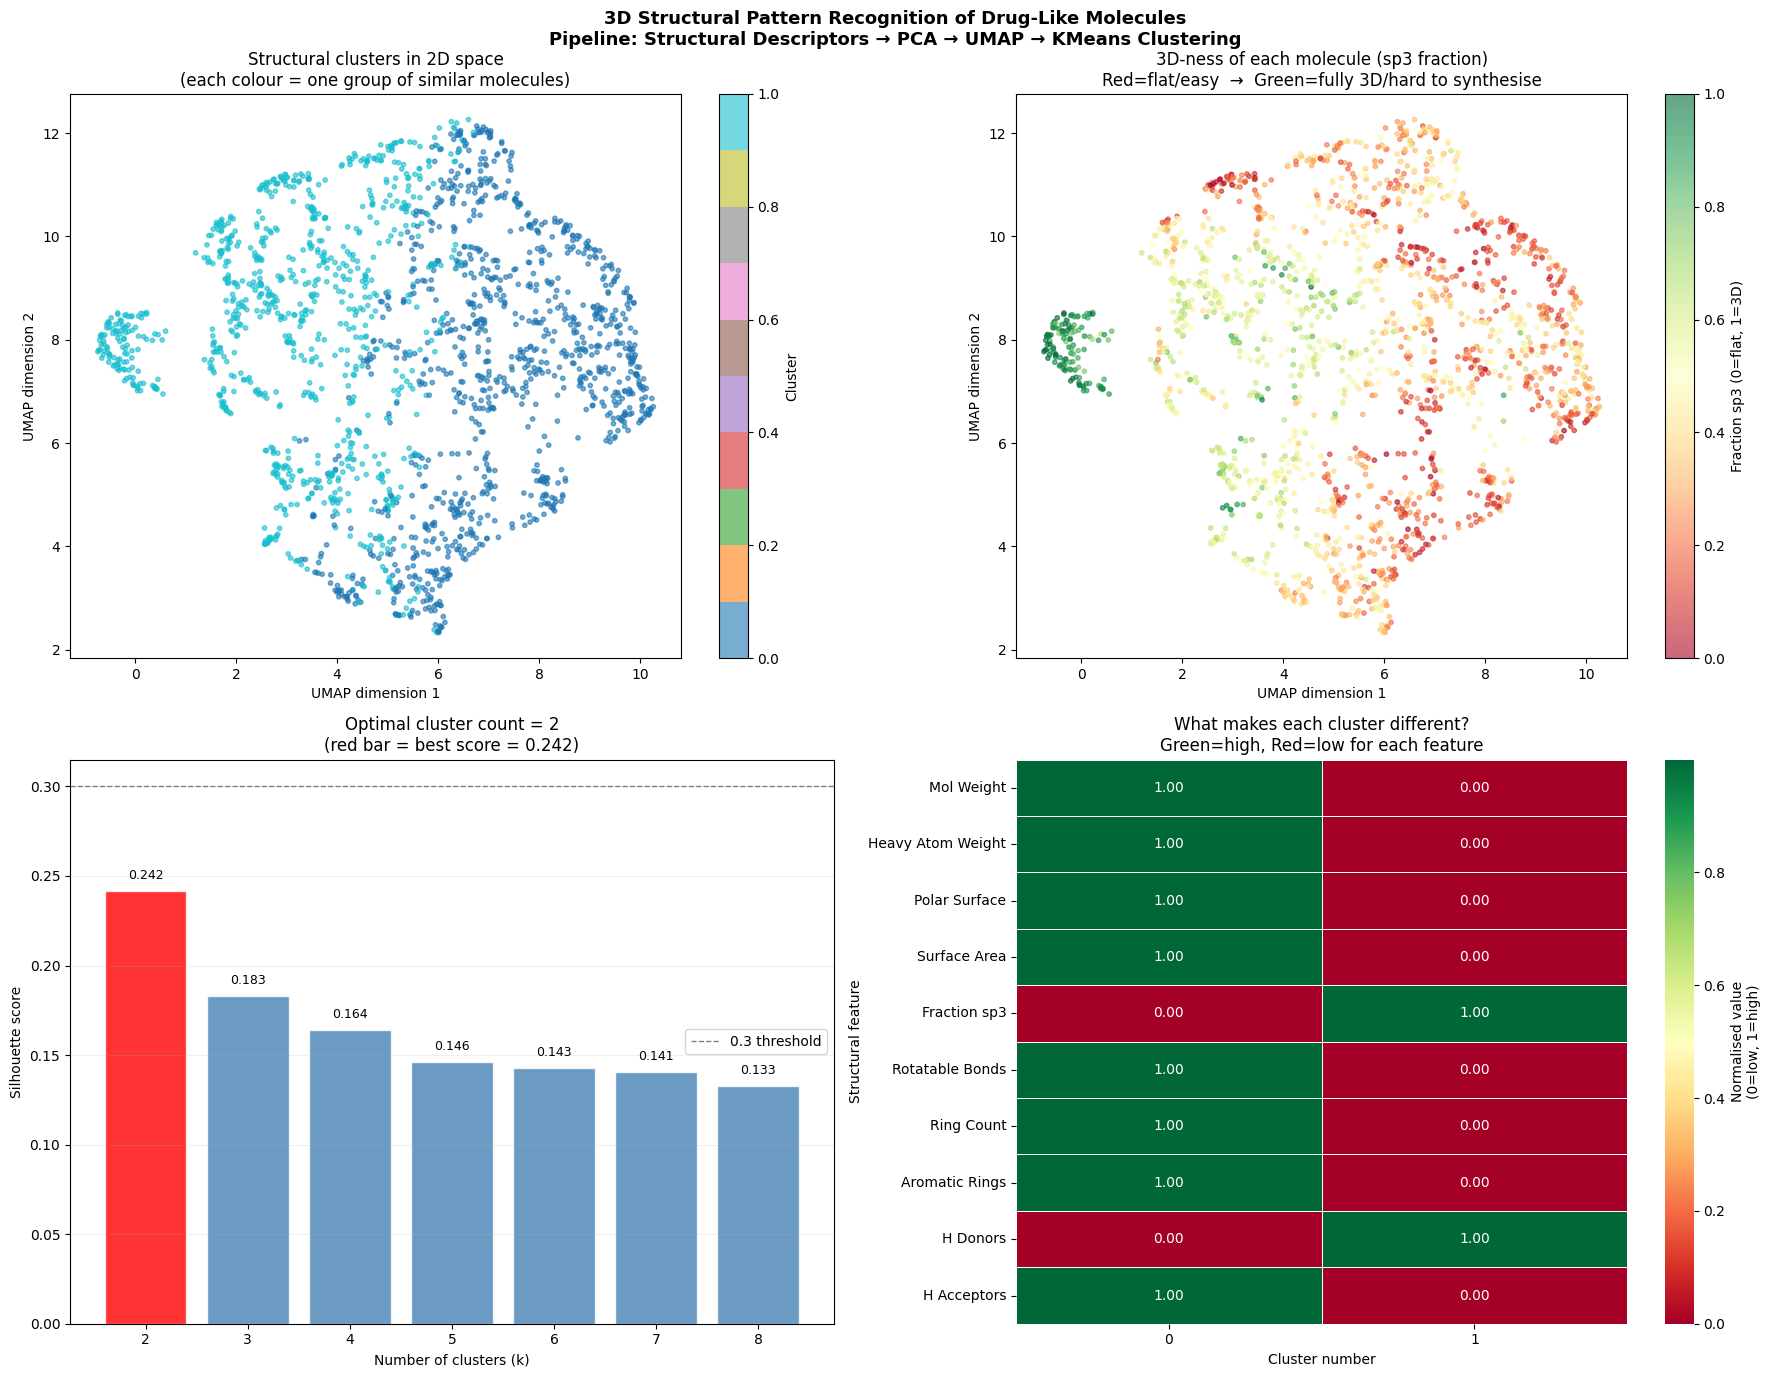

✅ Figure saved as 'structural_pattern_recognition.png'


In [10]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    '3D Structural Pattern Recognition of Drug-Like Molecules\n'
    'Pipeline: Structural Descriptors → PCA → UMAP → KMeans Clustering',
    fontsize=13, fontweight='bold'
)

# ── PLOT 1: Clusters on UMAP map ─────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
scatter = ax1.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=df_sample['cluster'],
    cmap='tab10', alpha=0.6, s=10
)
ax1.set_title('Structural clusters in 2D space\n'
              '(each colour = one group of similar molecules)')
ax1.set_xlabel('UMAP dimension 1')
ax1.set_ylabel('UMAP dimension 2')
plt.colorbar(scatter, ax=ax1, label='Cluster')

# ── PLOT 2: 3D-ness map ───────────────────────────────────────────────
# This is the key plot for Dr. Bradley
# It shows WHERE the synthesisability challenge lives in structure space
ax2 = fig.add_subplot(2, 2, 2)
scatter2 = ax2.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=df_features['Fraction sp3'],
    cmap='RdYlGn',
    alpha=0.6, s=10,
    vmin=0, vmax=1
)
ax2.set_title('3D-ness of each molecule (sp3 fraction)\n'
              'Red=flat/easy  →  Green=fully 3D/hard to synthesise')
ax2.set_xlabel('UMAP dimension 1')
ax2.set_ylabel('UMAP dimension 2')
plt.colorbar(scatter2, ax=ax2, label='Fraction sp3 (0=flat, 1=3D)')

# ── PLOT 3: Silhouette scores ─────────────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
colors = ['red' if k == best_k else 'steelblue' for k in k_values]
bars = ax3.bar(k_values, scores, color=colors, alpha=0.8, edgecolor='white')
ax3.set_xlabel('Number of clusters (k)')
ax3.set_ylabel('Silhouette score')
ax3.set_title(f'Optimal cluster count = {best_k}\n'
              f'(red bar = best score = {max(scores):.3f})')
ax3.axhline(y=0.3, color='gray', linestyle='--',
            linewidth=1, label='0.3 threshold')
ax3.legend()
ax3.grid(True, alpha=0.2, axis='y')
for bar, score in zip(bars, scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontsize=9)

# ── PLOT 4: Feature heatmap ───────────────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
cluster_means = df_features.groupby('cluster')[feature_names].mean()
norm = (cluster_means - cluster_means.min()) / \
       (cluster_means.max() - cluster_means.min() + 1e-8)
sns.heatmap(
    norm.T,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    ax=ax4,
    linewidths=0.5,
    cbar_kws={'label': 'Normalised value\n(0=low, 1=high)'}
)
ax4.set_title('What makes each cluster different?\n'
              'Green=high, Red=low for each feature')
ax4.set_xlabel('Cluster number')
ax4.set_ylabel('Structural feature')

plt.tight_layout()
plt.savefig('structural_pattern_recognition.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved as 'structural_pattern_recognition.png'")

In [11]:
print("=" * 60)
print("  RESULTS SUMMARY")
print("=" * 60)
print(f"  Dataset    : ZINC250k drug-like molecules")
print(f"  Sample     : {len(df_sample):,} molecules")
print(f"  Features   : {len(feature_names)} structural descriptors")
print(f"  Pipeline   : 10D → PCA(5D) → UMAP(2D) → KMeans")
print(f"  Clusters   : {best_k}  (silhouette = {max(scores):.3f})")
print("=" * 60)

sp3_by_cluster = df_features.groupby('cluster')['Fraction sp3'].mean()
most_3d_cluster  = sp3_by_cluster.idxmax()
least_3d_cluster = sp3_by_cluster.idxmin()

print("\n  Cluster-by-cluster breakdown:\n")
for c in sorted(df_sample['cluster'].unique()):
    sub  = df_features[df_features['cluster'] == c]
    mw   = sub['Mol Weight'].mean()
    sp3  = sub['Fraction sp3'].mean()
    ring = sub['Ring Count'].mean()
    arom = sub['Aromatic Rings'].mean()
    tpsa = sub['Polar Surface'].mean()
    n    = len(sub)

    if   sp3  > 0.5:  label = "3D-rich  → harder to synthesise"
    elif arom > 1.5:  label = "Aromatic → flat, easier to synthesise"
    elif mw   > 380:  label = "Large/heavy molecules"
    elif tpsa > 80:   label = "Highly polar molecules"
    else:             label = "Small drug-like molecules"

    print(f"  Cluster {c} — {label}")
    print(f"    Molecules : {n}")
    print(f"    Weight    : {mw:.0f} Da")
    print(f"    3D-ness   : {sp3:.2f}  {'▲ HIGH' if sp3>0.5 else '▼ low'}")
    print(f"    Rings     : {ring:.1f} total / {arom:.1f} aromatic")
    print(f"    Polarity  : {tpsa:.0f} Å²")
    print()

print("=" * 60)
print("  KEY FINDING:")
print(f"  Cluster {most_3d_cluster}  is the most 3D  "
      f"(sp3 = {sp3_by_cluster[most_3d_cluster]:.2f})")
print(f"  Cluster {least_3d_cluster}  is the flattest "
      f"(sp3 = {sp3_by_cluster[least_3d_cluster]:.2f})")
gap = sp3_by_cluster[most_3d_cluster] - sp3_by_cluster[least_3d_cluster]
print(f"  The {gap:.2f} gap in 3D-ness between clusters directly")
print(f"  represents the synthesisability challenge")
print("=" * 60)

  RESULTS SUMMARY
  Dataset    : ZINC250k drug-like molecules
  Sample     : 2,000 molecules
  Features   : 10 structural descriptors
  Pipeline   : 10D → PCA(5D) → UMAP(2D) → KMeans
  Clusters   : 2  (silhouette = 0.242)

  Cluster-by-cluster breakdown:

  Cluster 0 — Aromatic → flat, easier to synthesise
    Molecules : 1068
    Weight    : 374 Da
    3D-ness   : 0.31  ▼ low
    Rings     : 3.3 total / 2.4 aromatic
    Polarity  : 75 Å²

  Cluster 1 — 3D-rich  → harder to synthesise
    Molecules : 932
    Weight    : 289 Da
    3D-ness   : 0.53  ▲ HIGH
    Rings     : 2.1 total / 1.2 aromatic
    Polarity  : 55 Å²

  KEY FINDING:
  Cluster 1  is the most 3D  (sp3 = 0.53)
  Cluster 0  is the flattest (sp3 = 0.31)
  The 0.22 gap in 3D-ness between clusters directly
  represents the synthesisability challenge
